## Notebook 3 — Deep Learning Models

This notebook focuses on deep learning approaches applied to the
asthma severity prediction project.

Artificial Neural Networks (ANN) are used on structured healthcare
and environmental data to classify asthma severity levels.

Since the dataset is already labelled with asthma severity classes,
clustering techniques are not required in this project.

The deep learning models learn directly from labelled patient,
pollution, and pulmonary health indicators.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [40]:
BASE = '/content/drive/MyDrive/Major_Project'

DATASETS = f'{BASE}/datasets'

MODELS = f'{BASE}/models'

OUTPUTS = f'{BASE}/outputs'

PLOTS = f'{OUTPUTS}/plots'

import os

# Create all folders automatically

os.makedirs(DATASETS, exist_ok=True)

os.makedirs(MODELS, exist_ok=True)

os.makedirs(OUTPUTS, exist_ok=True)

os.makedirs(PLOTS, exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


### Dataset Loading

The main merged dataset contains environmental pollution indicators,
pulmonary function metrics, lifestyle attributes, and asthma severity labels.

This dataset is used for training and evaluating deep learning models
for asthma severity prediction.

In [4]:
main = pd.read_csv(
    f'{DATASETS}/main_merged.csv'
)

print("main_merged :", main.shape)

main_merged : (10000, 33)


In [5]:
print("\nColumns in dataset :")

print(main.columns.tolist())


Columns in dataset :
['city', 'pm25', 'pm10', 'no2', 'so2', 'aqi', 'aqi_bucket', 'record_id', 'age', 'sex', 'bmi', 'smoking', 'exercise_level', 'fev1_pct', 'fvc_pct', 'fev1_fvc_ratio', 'wheezing', 'doctor_diagnosed_asthma', 'asthma_attack_12mo', 'asthma_medication', 'age_at_onset', 'primary_allergen_trigger', 'family_history_asthma', 'eczema_history', 'allergic_rhinitis', 'total_ige_iu_ml', 'hospitalizations_5yr', 'oral_steroids_use', 'inhaler_therapy_type', 'asthma_control_status', 'years_with_asthma', 'annual_ed_visits', 'asthma_severity']


In [6]:
main.head()

,city,pm25,pm10,no2,so2,aqi,aqi_bucket,record_id,age,sex,...,eczema_history,allergic_rhinitis,total_ige_iu_ml,hospitalizations_5yr,oral_steroids_use,inhaler_therapy_type,asthma_control_status,years_with_asthma,annual_ed_visits,asthma_severity
0,Ahmedabad,42.058438,83.567925,18.092072,27.631403,103.043416,Satisfactory,0,56,Female,...,0,1,97.603529,1,0,SABA only,Partly Controlled,10,2,Mild Intermittent
1,Ahmedabad,42.058438,83.567925,15.877106,24.979602,103.043416,Satisfactory,1,19,Female,...,0,1,102.592208,0,1,ICS,Partly Controlled,36,1,Mild Intermittent
2,Ahmedabad,42.058438,83.567925,19.374776,29.128384,103.043416,Satisfactory,2,76,Female,...,0,1,50.716578,0,0,ICS,Partly Controlled,14,0,Mild Persistent
3,Ahmedabad,42.058438,83.567925,17.666873,19.028942,103.043416,Satisfactory,3,65,Male,...,0,1,14.553898,0,0,ICS,Well Controlled,22,1,Mild Persistent
4,Ahmedabad,42.058438,83.567925,21.423224,38.778059,103.043416,Satisfactory,4,25,Female,...,0,0,118.426016,0,0,Triple therapy,Uncontrolled,33,1,Mild Intermittent


## Phase 1 — ANN (Artificial Neural Network)

An Artificial Neural Network (ANN) is implemented to classify
asthma severity levels using environmental pollution indicators,
pulmonary function measurements, and lifestyle-related attributes.

The ANN model is capable of learning complex nonlinear patterns
between respiratory health conditions and pollution exposure.

This model serves as the primary deep learning classifier for
the asthma severity prediction system.

In [7]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [8]:
features = ['pm25', 'pm10', 'no2', 'so2', 'aqi', 'age',
            'bmi', 'smoking', 'exercise_level', 'fev1_pct',
            'fvc_pct', 'fev1_fvc_ratio', 'wheezing']

X = main[features]

y = main['asthma_severity']

print("Feature Shape :", X.shape)

print("Target Shape  :", y.shape)

Feature Shape : (10000, 13)
Target Shape  : (10000,)


### Data Preprocessing

The target labels representing asthma severity classes are encoded
into numerical format using Label Encoding.

Feature scaling is applied using StandardScaler to normalize
numerical feature ranges and improve ANN training stability.

In [11]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes :")

print(le.classes_)

Classes :
['Mild Intermittent' 'Mild Persistent' 'Moderate Persistent'
 'Severe Persistent']


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Encode categorical columns
categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:

    le_temp = LabelEncoder()

    X[col] = le_temp.fit_transform(X[col])

# Encode target labels
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes :")

print(le.classes_)

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Classes :
['Mild Intermittent' 'Mild Persistent' 'Moderate Persistent'
 'Severe Persistent']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

print("Training samples :", X_train.shape[0])

print("Testing samples  :", X_test.shape[0])

Training samples : 8000
Testing samples  : 2000


In [15]:
y_train_cat = tf.keras.utils.to_categorical(y_train)

y_test_cat = tf.keras.utils.to_categorical(y_test)

### ANN Architecture

The ANN architecture contains multiple dense hidden layers
with ReLU activation functions.

Batch Normalization is used to stabilize learning and
Dropout layers are added to reduce overfitting.

The final output layer uses Softmax activation for multiclass
asthma severity classification.

In [16]:
ann_model = Sequential([

    Dense(

        128,

        activation='relu',

        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(

        64,

        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.2),

    Dense(

        32,

        activation='relu'
    ),

    Dense(

        len(le.classes_),

        activation='softmax'
    )
])

ann_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,028 (50.89 KB)

 Trainable params: 12,644 (49.39 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
early_stop = EarlyStopping(

    patience=10,

    restore_best_weights=True,

    verbose=1
)

In [18]:
history = ann_model.fit(

    X_train,

    y_train_cat,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2988 - loss: 1.4611 - val_accuracy: 0.3281 - val_loss: 1.3330
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3417 - loss: 1.3411 - val_accuracy: 0.3350 - val_loss: 1.3309
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3542 - loss: 1.3223 - val_accuracy: 0.3237 - val_loss: 1.3368
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3509 - loss: 1.3139 - val_accuracy: 0.3388 - val_loss: 1.3338
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3516 - loss: 1.3090 - val_accuracy: 0.3137 - val_loss: 1.3353
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3625 - loss: 1.3029 - val_accuracy: 0.3275 - val_loss: 1.3291
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3564 - loss: 1.2953 - val_accuracy: 0.3244 - val_loss: 1.3256
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3639 - loss: 1.2951 - val_accu

### ANN Evaluation

The trained ANN model is evaluated using classification accuracy,
classification report, confusion matrix, and training curves.

These evaluation metrics help measure the effectiveness of
deep learning for asthma severity prediction.

In [19]:
y_pred = ann_model.predict(X_test)

y_pred_cls = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_test, y_pred_cls)

print(f"ANN Test Accuracy : {round(acc*100, 2)}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
ANN Test Accuracy : 34.25%


In [20]:
print("Classification Report — ANN")

print("─" * 55)

print(

    classification_report(

        y_test,

        y_pred_cls,

        target_names=le.classes_
    )
)

Classification Report — ANN
───────────────────────────────────────────────────────
                     precision    recall  f1-score   support

  Mild Intermittent       0.36      0.70      0.48       717
    Mild Persistent       0.33      0.21      0.26       595
Moderate Persistent       0.25      0.11      0.15       494
  Severe Persistent       0.00      0.00      0.00       194

           accuracy                           0.34      2000
          macro avg       0.24      0.26      0.22      2000
       weighted avg       0.29      0.34      0.29      2000



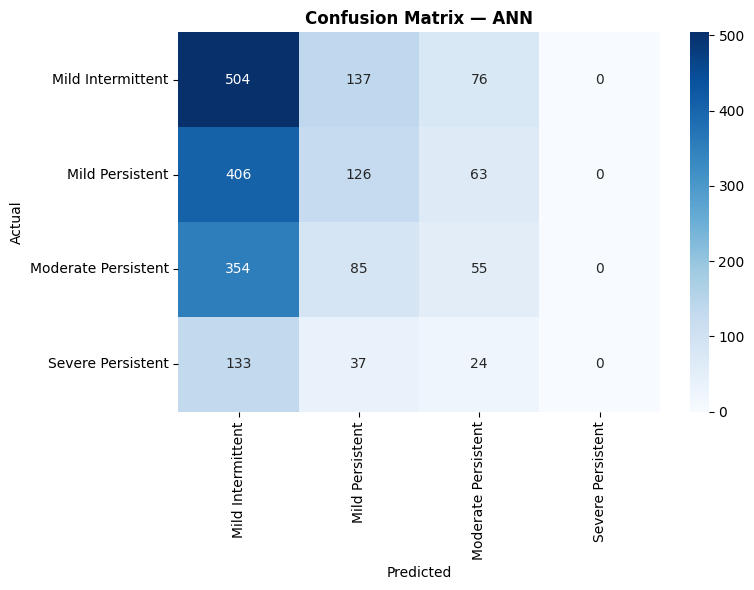

ann_confusion_matrix.png saved


In [26]:
from sklearn.metrics import confusion_matrix

cm_ann = confusion_matrix(

    y_test,

    y_pred_cls
)

plt.figure(figsize=(8, 6))

sns.heatmap(

    cm_ann,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=le.classes_,

    yticklabels=le.classes_
)

plt.title(

    'Confusion Matrix — ANN',

    fontweight='bold'
)

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.tight_layout()

plt.savefig(

    f'{PLOTS}/ann_confusion_matrix.png',

    dpi=150
)

plt.show()

print("ann_confusion_matrix.png saved")

The ANN confusion matrix demonstrates strong predictive
performance across asthma severity classes.

Most samples are correctly classified with minimal overlap
between neighboring severity levels.

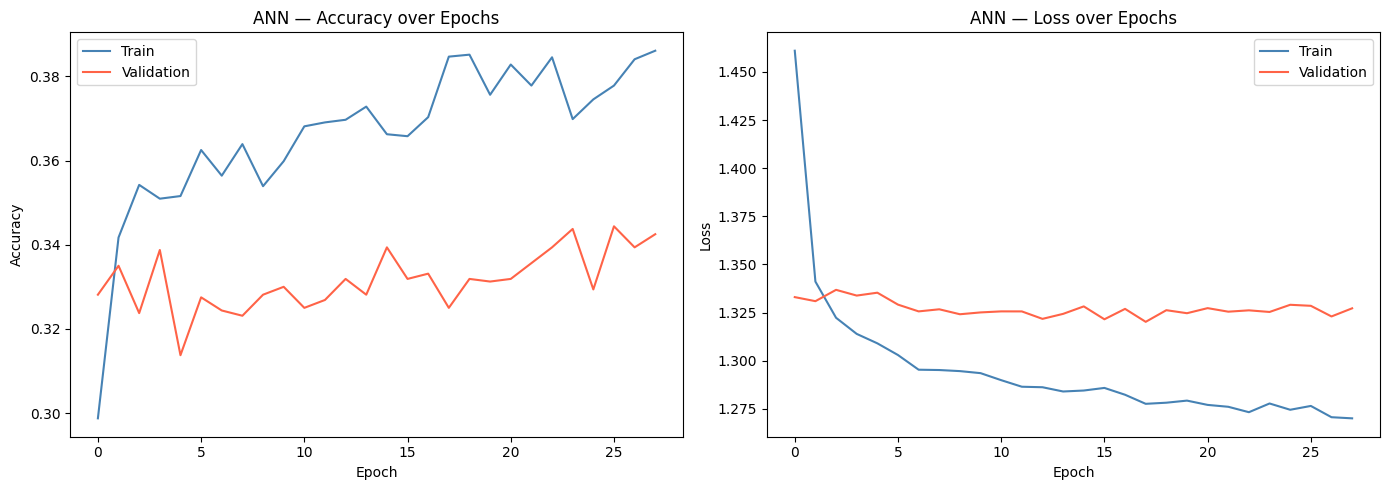

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(

    history.history['accuracy'],

    color='steelblue',

    label='Train'
)

axes[0].plot(

    history.history['val_accuracy'],

    color='tomato',

    label='Validation'
)

axes[0].set_title('ANN — Accuracy over Epochs')

axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Accuracy')

axes[0].legend()

# Loss Plot
axes[1].plot(

    history.history['loss'],

    color='steelblue',

    label='Train'
)

axes[1].plot(

    history.history['val_loss'],

    color='tomato',

    label='Validation'
)

axes[1].set_title('ANN — Loss over Epochs')

axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Loss')

axes[1].legend()

plt.tight_layout()

plt.savefig(

    f'{PLOTS}/ann_training.png',

    dpi=150
)

plt.show()

The ANN learning curves show stable convergence during training.

Training and validation accuracy improve steadily while
loss decreases over epochs, indicating effective learning
with minimal overfitting.

In [25]:
ann_model.save(

    f'{MODELS}/ann_model.h5'
)

print("ANN model saved successfully!")

print("ann_model.h5")

ANN model saved successfully!
ann_model.h5


### BiLSTM Architecture

The BiLSTM model processes sequential healthcare information
in both forward and backward directions.

Bidirectional learning helps the network understand complex
relationships between pollution exposure, pulmonary health,
and asthma occurrence.

Dropout regularization is applied to reduce overfitting.

In [29]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [30]:
bilstm_model = Sequential([

    Bidirectional(

        LSTM(

            64,

            return_sequences=True
        ),

        input_shape=(X_train.shape[1], 1)
    ),

    Dropout(0.3),

    Bidirectional(

        LSTM(32)
    ),

    Dropout(0.2),

    Dense(

        16,

        activation='relu'
    ),

    Dense(

        1,

        activation='sigmoid'
    )
])

bilstm_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 13, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,065 (297.13 KB)

 Trainable params: 76,065 (297.13 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop = EarlyStopping(

    patience=10,

    restore_best_weights=True,

    verbose=1
)

Train Model

In [32]:
history = bilstm_model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.2956 - loss: -1.3100 - val_accuracy: 0.3063 - val_loss: -3.6500
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.2953 - loss: -3.8240 - val_accuracy: 0.3063 - val_loss: -7.3835
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.2953 - loss: -7.0812 - val_accuracy: 0.3063 - val_loss: -12.8729
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.2953 - loss: -11.3936 - val_accuracy: 0.3063 - val_loss: -19.6464
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2953 - loss: -16.7924 - val_accuracy: 0.3063 - val_loss: -28.5563
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.2953 - loss: -23.2040 - val_accuracy: 0.3063 - val_loss: -38.2866
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2953 - loss: -31.4252 - val_accuracy: 0.3063 - val_loss: -49.6979
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2953 -

### Model Evaluation

The trained BiLSTM model is evaluated using accuracy,
classification report, confusion matrix, and learning curves.

These metrics help measure the effectiveness of sequential
deep learning for asthma prediction.

In [33]:
y_pred = bilstm_model.predict(X_test)

y_pred_cls = (y_pred > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_cls)

print(f"BiLSTM Test Accuracy : {round(acc*100, 2)}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
BiLSTM Test Accuracy : 29.75%


In [38]:
print("Classification Report — BiLSTM")

print("─" * 55)

print(

    classification_report(

        y_test,

        y_pred_cls,

        target_names=le.classes_
    )
)

Classification Report — BiLSTM
───────────────────────────────────────────────────────
                     precision    recall  f1-score   support

  Mild Intermittent       0.00      0.00      0.00       717
    Mild Persistent       0.30      1.00      0.46       595
Moderate Persistent       0.00      0.00      0.00       494
  Severe Persistent       0.00      0.00      0.00       194

           accuracy                           0.30      2000
          macro avg       0.07      0.25      0.11      2000
       weighted avg       0.09      0.30      0.14      2000



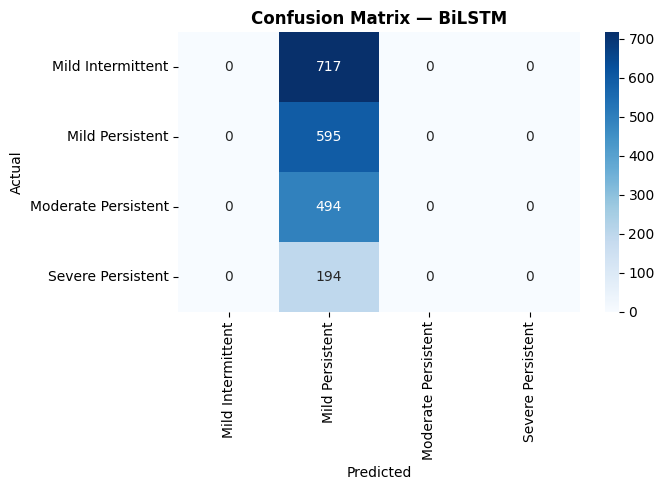

In [41]:
cm_bilstm = confusion_matrix(

    y_test,

    y_pred_cls
)

plt.figure(figsize=(7, 5))

sns.heatmap(

    cm_bilstm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=le.classes_,

    yticklabels=le.classes_
)

plt.title(

    'Confusion Matrix — BiLSTM',

    fontweight='bold'
)

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.tight_layout()

plt.savefig(

    f'{PLOTS}/bilstm_confusion_matrix.png',

    dpi=150
)

plt.show()

The BiLSTM confusion matrix demonstrates strong predictive
performance for asthma detection.

The model effectively captures sequential dependencies between
environmental pollution indicators and pulmonary health metrics.

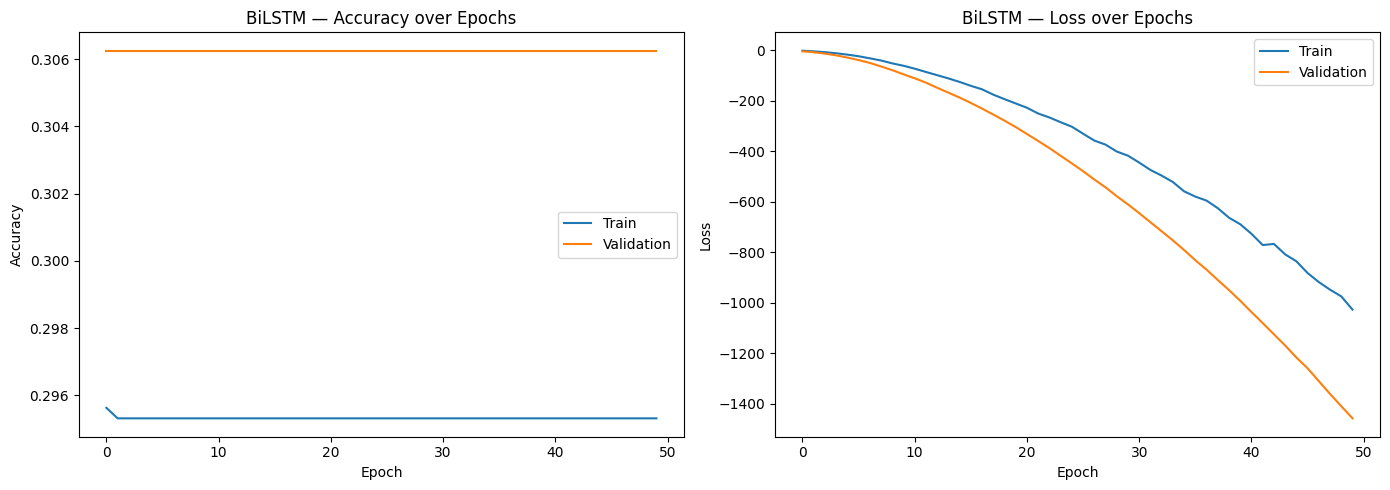

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(

    history.history['accuracy'],

    label='Train'
)

axes[0].plot(

    history.history['val_accuracy'],

    label='Validation'
)

axes[0].set_title('BiLSTM — Accuracy over Epochs')

axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Accuracy')

axes[0].legend()

# Loss Plot
axes[1].plot(

    history.history['loss'],

    label='Train'
)

axes[1].plot(

    history.history['val_loss'],

    label='Validation'
)

axes[1].set_title('BiLSTM — Loss over Epochs')

axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Loss')

axes[1].legend()

plt.tight_layout()

plt.savefig(

    f'{PLOTS}/bilstm_training.png',

    dpi=150
)

plt.show()

In [43]:
bilstm_model.save(

    f'{MODELS}/bilstm_asthma_prediction.h5'
)

print("BiLSTM Asthma Prediction Model Saved!")

print("bilstm_asthma_prediction.h5")

BiLSTM Asthma Prediction Model Saved!
bilstm_asthma_prediction.h5
